In [75]:
import numpy as np
import pandas as pd

In [76]:
df = pd.read_csv("job_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021e,EN,FT,Data Science Consultant,54000,EUR,64369,DE,50,DE,L
1,2020,SE,FT,Data Scientist,60000,EUR,68428,GR,100,US,L
2,2021e,EX,FT,Head of Data Science,85000,USD,85000,RU,0,RU,M
3,2021e,EX,FT,Head of Data,230000,USD,230000,RU,50,RU,L
4,2021e,EN,FT,Machine Learning Engineer,125000,USD,125000,US,100,US,S


In [78]:
df.shape

(245, 11)

In [79]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           245 non-null    object
 1   experience_level    245 non-null    object
 2   employment_type     245 non-null    object
 3   job_title           245 non-null    object
 4   salary              245 non-null    int64 
 5   salary_currency     245 non-null    object
 6   salary_in_usd       245 non-null    int64 
 7   employee_residence  245 non-null    object
 8   remote_ratio        245 non-null    int64 
 9   company_location    245 non-null    object
 10  company_size        245 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.2+ KB


In [81]:
#checking missing values
#df.isnull()
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [82]:
df.describe()

,salary,salary_in_usd,remote_ratio
count,2.450000e+02,245.000000,245.000000
mean,5.025418e+05,99868.012245,69.183673
std,2.276230e+06,83983.326949,37.593421
min,4.000000e+03,2876.000000,0.000000
25%,6.000000e+04,45896.000000,50.000000
50%,1.030000e+05,81000.000000,100.000000
75%,1.740000e+05,130000.000000,100.000000
max,3.040000e+07,600000.000000,100.000000


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

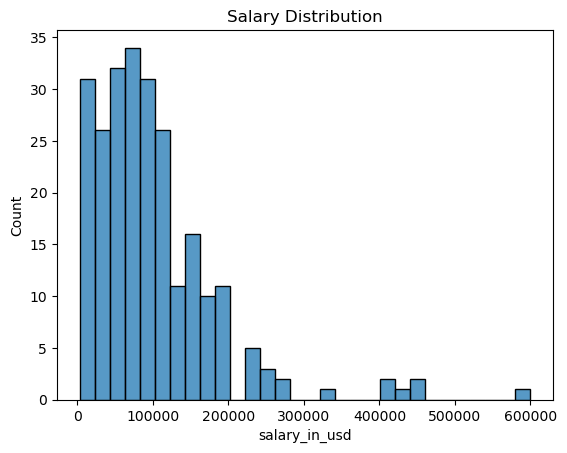

In [84]:
sns.histplot(df['salary_in_usd'],bins=30)
plt.title("Salary Distribution")
plt.show()

In [85]:
# Observation:
# The salary distribution is right-skewed.
# This means - Most salaries lie between 0–150k(left side), while a few high salaries (up to 600k)(right side) 
# create a long right tail, indicating presence of outliers.

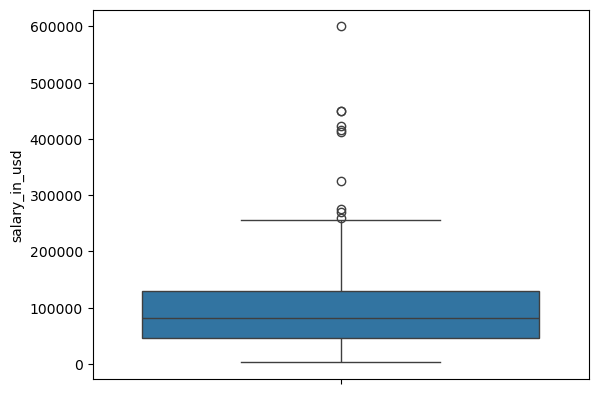

In [86]:
sns.boxplot(y=df['salary_in_usd'])
plt.show()

In [87]:
# Observation:
# The boxplot shows several high-value outliers above ~250k.
# Most salaries lie between 50k–120k, with median around ~85k.
# Extreme salaries (300k–600k) are clearly visible as outliers.

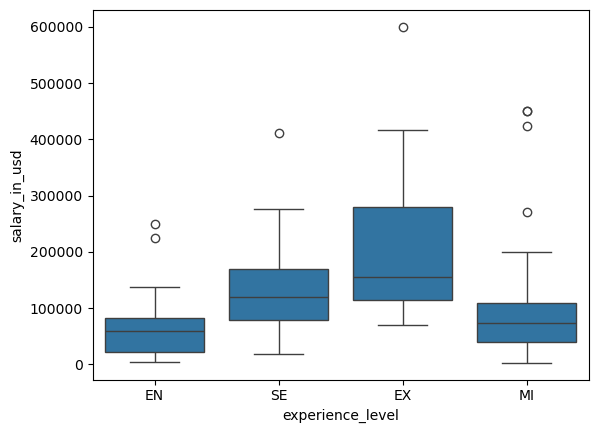

In [88]:
sns.boxplot(x='experience_level',y='salary_in_usd',data=df)
plt.show()

In [89]:
# Observation:
# Salary increases significantly with experience level.
# Executive (EX) roles have the highest median salary, followed by Senior (SE).
# Entry-level (EN) roles have the lowest salaries.
# Higher experience levels also show greater salary variation and more extreme outliers.

In [90]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [91]:
# instead of using axis=1(meaning columns), use-> df.drop(columns=['salary', 'job_title'])
df = df.drop(columns=['salary','salary_currency','employee_residence','company_location','job_title'])

In [92]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'salary_in_usd',
       'remote_ratio', 'company_size'],
      dtype='object')

In [93]:
df.head()

,work_year,experience_level,employment_type,salary_in_usd,remote_ratio,company_size
0,2021e,EN,FT,64369,50,L
1,2020,SE,FT,68428,100,L
2,2021e,EX,FT,85000,0,M
3,2021e,EX,FT,230000,50,L
4,2021e,EN,FT,125000,100,S


In [94]:
df=pd.get_dummies(df,drop_first=True)#One Hot encoding
df = df.astype(int) # to convert true false to 0/1
# or use this to directly get 0/1 values-> pd.get_dummies(df, drop_first=True, dtype=int)

In [95]:
df.head()

,salary_in_usd,remote_ratio,work_year_2021e,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_FL,employment_type_FT,employment_type_PT,company_size_M,company_size_S
0,64369,50,1,0,0,0,0,1,0,0,0
1,68428,100,0,0,0,1,0,1,0,0,0
2,85000,0,1,1,0,0,0,1,0,1,0
3,230000,50,1,1,0,0,0,1,0,0,0
4,125000,100,1,0,0,0,0,1,0,0,1


In [96]:
df.columns

Index(['salary_in_usd', 'remote_ratio', 'work_year_2021e',
       'experience_level_EX', 'experience_level_MI', 'experience_level_SE',
       'employment_type_FL', 'employment_type_FT', 'employment_type_PT',
       'company_size_M', 'company_size_S'],
      dtype='object')

In [97]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['salary_in_usd'])
y = df['salary_in_usd']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [98]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [99]:
y_pred = model.predict(X_test)

In [100]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import numpy as np

In [101]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE=",mae)

MAE= 50029.720299752524


In [102]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE=",rmse)

RMSE= 78800.25742664404


In [103]:
comparison = pd.DataFrame({'Actual':y_test,
                           'Predicted':y_pred})
comparison.head()

,Actual,Predicted
24,47681,87922.995693
6,450000,45451.233107
153,5695,87922.995693
212,19052,79812.451134
199,21669,2798.408568


In [104]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [105]:
comparison = pd.DataFrame({'Actual':y_test,
                           'Predicted':y_pred})
comparison.head()

,Actual,Predicted
24,47681,46416.666667
6,450000,63837.000000
153,5695,46416.666667
212,19052,127500.000000
199,21669,28850.000000


In [106]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [107]:
comparison = pd.DataFrame({'Actual':y_test,
                           'Predicted':y_pred})
comparison.head()

,Actual,Predicted
24,47681,48725.684746
6,450000,65096.045048
153,5695,48725.684746
212,19052,115665.048541
199,21669,37238.761667


In [108]:
df.columns

Index(['salary_in_usd', 'remote_ratio', 'work_year_2021e',
       'experience_level_EX', 'experience_level_MI', 'experience_level_SE',
       'employment_type_FL', 'employment_type_FT', 'employment_type_PT',
       'company_size_M', 'company_size_S'],
      dtype='object')

In [109]:
#again loading dataset and not dropping any feature
df = pd.read_csv('job_salaries.csv')

In [110]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [111]:
df['job_title'].value_counts()

job_title
Data Scientist                              59
Data Engineer                               38
Machine Learning Engineer                   20
Data Analyst                                20
Research Scientist                          10
Data Science Consultant                      7
Big Data Engineer                            6
Data Science Manager                         5
Lead Data Engineer                           5
BI Data Analyst                              5
AI Scientist                                 5
Principal Data Scientist                     5
Director of Data Science                     4
Machine Learning Scientist                   4
Data Engineering Manager                     3
Business Data Analyst                        3
ML Engineer                                  3
Data Analytics Engineer                      3
Lead Data Analyst                            3
Data Analytics Manager                       3
Computer Vision Engineer                     3
Com

In [112]:
def categorize_job(title):
    title = title.lower()

    if 'data scientist' in title:
        return 'Data Scientist'

    elif 'machine learning' in title or 'ml' in title or 'ai' in title or 'vision' in title:
        return 'ML/AI'

    elif 'analyst' in title:
        return 'Data Analyst'

    elif 'engineer' in title or 'architect' in title:
        return 'Data Engineer'

    elif 'manager' in title or 'director' in title or 'head' in title:
        return 'Management'

    else:
        return 'Other'

df['job_title'] = df['job_title'].apply(categorize_job)

In [113]:
df = df.drop([
    'company_location',
    'employee_residence',
    'salary',
    'salary_currency'
], axis=1)

In [114]:
df['job_title'].value_counts()

job_title
Data Scientist    68
Data Engineer     65
ML/AI             41
Data Analyst      36
Other             18
Management        17
Name: count, dtype: int64

In [115]:
df = pd.get_dummies(df, drop_first=True,dtype=int)

In [116]:
df.head()

,salary_in_usd,remote_ratio,work_year_2021e,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_FL,employment_type_FT,employment_type_PT,job_title_Data Engineer,job_title_Data Scientist,job_title_ML/AI,job_title_Management,job_title_Other,company_size_M,company_size_S
0,64369,50,1,0,0,0,0,1,0,0,0,0,0,1,0,0
1,68428,100,0,0,0,1,0,1,0,0,1,0,0,0,0,0
2,85000,0,1,1,0,0,0,1,0,0,0,0,1,0,1,0
3,230000,50,1,1,0,0,0,1,0,0,0,0,1,0,0,0
4,125000,100,1,0,0,0,0,1,0,0,0,1,0,0,0,1


In [117]:
df.columns

Index(['salary_in_usd', 'remote_ratio', 'work_year_2021e',
       'experience_level_EX', 'experience_level_MI', 'experience_level_SE',
       'employment_type_FL', 'employment_type_FT', 'employment_type_PT',
       'job_title_Data Engineer', 'job_title_Data Scientist',
       'job_title_ML/AI', 'job_title_Management', 'job_title_Other',
       'company_size_M', 'company_size_S'],
      dtype='object')

In [118]:
[col for col in df.columns if 'job_title' in col]# to find a particular column in case of many columns

['job_title_Data Engineer',
 'job_title_Data Scientist',
 'job_title_ML/AI',
 'job_title_Management',
 'job_title_Other']

In [119]:
len(df.columns)

16

In [120]:
# Performed feature engineering by grouping job titles into meaningful categories 
#and encoding categorical variables.

# Also performed feature selection by removing high-cardinality and irrelevant features 
#like company location/salary currency to reduce overfitting.

In [121]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['salary_in_usd'])
y = df['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [144]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [123]:
y_pred = model.predict(X_test)

In [124]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 50573.99743489368
RMSE: 76530.08134397362


In [125]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head()

,Actual,Predicted
24,47681,106863.830181
6,450000,76804.354667
153,5695,44501.901637
212,19052,148013.175603
199,21669,40247.505875


In [126]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

experience_level_EX         0.207615
remote_ratio                0.143455
experience_level_SE         0.117002
job_title_Data Engineer     0.082731
job_title_ML/AI             0.080523
company_size_S              0.069020
company_size_M              0.065257
work_year_2021e             0.058227
job_title_Data Scientist    0.046693
experience_level_MI         0.042968
employment_type_FT          0.034549
job_title_Management        0.023390
job_title_Other             0.018756
employment_type_PT          0.007424
employment_type_FL          0.002391
dtype: float64


In [127]:
# target
y = np.log(df['salary_in_usd'])

# features
X = df.drop(columns=['salary_in_usd'])

# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# convert back
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred)

In [128]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_actual, y_pred_actual)
print(mae)

49430.72068435243


In [129]:
df['salary_in_usd'].mean()

99868.01224489795

In [130]:
q1 = df['salary_in_usd'].quantile(0.25)
q3 = df['salary_in_usd'].quantile(0.75)

iqr = q3 - q1

df = df[(df['salary_in_usd'] >= q1 - 1.5*iqr) & 
        (df['salary_in_usd'] <= q3 + 1.5*iqr)]

In [131]:
df = pd.read_csv('job_salaries.csv')
df['role_experience'] = df['job_title'] + "_" + df['experience_level']

In [132]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_actual, y_pred_actual)
print("Real MAE:", mae)

Real MAE: 49050.878010729335


In [143]:
comparison = pd.DataFrame({
    'Actual': y_test_actual,
    'Predicted': y_pred_actual
})

comparison.head()

,Actual,Predicted
24,47681.0,68501.967478
6,450000.0,63768.069919
153,5695.0,36231.945847
212,19052.0,132513.251000
199,21669.0,19700.967919


In [134]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

experience_level_SE         0.150307
remote_ratio                0.147197
experience_level_EX         0.102719
experience_level_MI         0.073076
employment_type_PT          0.072584
company_size_S              0.066601
job_title_Data Engineer     0.066025
job_title_ML/AI             0.059089
company_size_M              0.054815
work_year_2021e             0.052770
job_title_Data Scientist    0.042834
employment_type_FT          0.041803
job_title_Other             0.032463
job_title_Management        0.018910
employment_type_FL          0.018807
dtype: float64


In [135]:
#The dataset lacks key predictors like years of experience and company information. Because of this, 
#similar feature combinations map to very different salaries, leading to high variance. 
#Even after applying log transformation and ensemble models, the model regresses toward the mean. 
#This reflects a data limitation rather than a modeling issue

In [136]:
import numpy as np

# baseline prediction (mean of log values)
mean_log = y_train.mean()

# predict in log space
y_pred_baseline_log = [mean_log] * len(y_test)

# convert to real salary
y_pred_baseline = np.exp(y_pred_baseline_log)
y_test_actual = np.exp(y_test)

# calculate real MAE
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(y_test_actual, y_pred_baseline)

print("Baseline MAE (real):", baseline_mae)

Baseline MAE (real): 56972.26521543525


In [137]:
#Compared my model with a baseline mean predictor which had an MAE of ~57k. 
#My Random Forest model reduced this to ~49k, achieving around 14% improvement. 
#The remaining error is due to missing key features like experience years and company data, 
#leading to high variance.

In [138]:
print("Baseline MAE:", baseline_mae)
print("Model MAE:", mae)

Baseline MAE: 56972.26521543525
Model MAE: 49050.878010729335


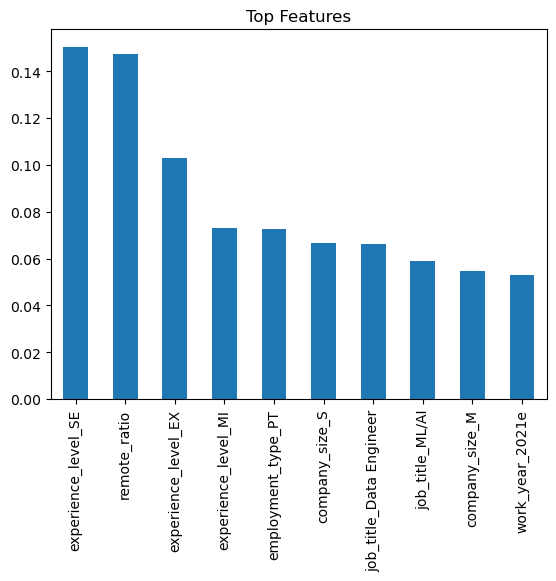

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

In [140]:
#Remote ratio and experience level had highest impact on salary

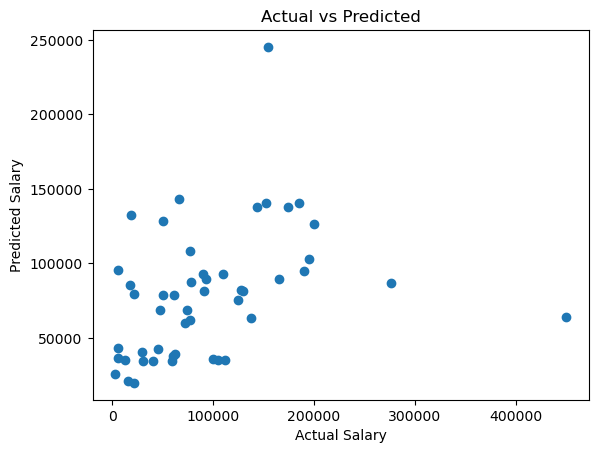

In [141]:
plt.scatter(y_test_actual, y_pred_actual)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [142]:
comparison['Error'] = abs(comparison['Actual'] - comparison['Predicted'])

comparison.sort_values(by='Error', ascending=False).head()

,Actual,Predicted,Error
177,8.711443,11.468864,2.757421
156,7.964156,10.163880,2.199724
172,8.649449,10.675277,2.025829
6,13.017003,11.063008,1.953995
212,9.854927,11.794438,1.939511


In [72]:
#The model achieved a Mean Absolute Error of approximately $49,000, improving upon a 
#baseline error of $57,000 by ~14%.
#Despite applying feature engineering, encoding, and ensemble models, prediction accuracy
#remains limited due to missing key features such as years of experience and company-level information.

#The analysis highlights that salary prediction is inherently complex and influenced by multiple unobserved factors.

In [145]:
import joblib
joblib.dump(model, "salary_model.pkl")
print("Model saved successfully")

Model saved successfully


In [146]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")
print("Columns saved")

Columns saved


In [148]:
import os
os.listdir()

['.ipynb_checkpoints',
 'EDA.ipynb',
 'job_salaries.csv',
 'model_columns.pkl',
 'salary_model.pkl']